# Host rate figures

Reads the host-rate TSVs already produced from the BEAST `.trees` files and
draws one density figure per panel.

**Input:** a folder of wide-format TSVs, one per BEAST run. Each file has a
`tree_index` column plus rate and branch-count columns named
`<partition_prefix>.rate__<group>` and `<partition_prefix>.rate__n_<group>`.

**What the notebook does**

1. loads every TSV in the folder and reshapes it to long format
2. prints an inventory so you can see which groups exist in which file
3. draws one figure per panel from the `FIGURES` configuration
4. writes a summary table of means and 95% HPD intervals


In [11]:
import re
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

DATA_DIR = Path("../data/Host_rates_all")      # folder holding the TSVs
OUT_DIR  = Path("../figures")        # where figures are written
OUT_DIR.mkdir(exist_ok=True)

# x-axis range and ticks shared by every panel
XMIN, XMAX = 3e-4, 4e-3
XTICKS = (1e-4, 2e-4, 3e-4, 1e-3, 2e-3, 4e-3, 1e-2)

PARTITION_NAMES = {"SPIKE": "Spike", "S": "Spike", "ORF1A": "ORF1a",
                   "ORF1B": "ORF1b", "N": "N", "M": "M", "E": "E"}
PARTITION_ORDER = ["Spike", "ORF1a", "ORF1b", "N", "M", "E"]

## 1. Load

`load_folder` turns every wide TSV into long rows of
`run, tree_index, partition, group, rate, n_branches`. The run label is the
file stem, which is how a series is addressed later as `run/group`.

In [12]:
def partition_label(prefix: str) -> str:
    tokens = prefix.split("_")
    for tok in tokens[:3]:
        if tok.upper() in PARTITION_NAMES:
            return PARTITION_NAMES[tok.upper()]
    for tok in tokens:
        if not re.fullmatch(r"\d+[a-z]?", tok):
            return tok
    return prefix


def load_wide(path: Path) -> pd.DataFrame:
    """One wide TSV -> long rows."""
    df = pd.read_csv(path, sep="\t")
    df.columns = [c.strip() for c in df.columns]

    rates, counts = {}, {}
    for col in df.columns:
        if "__" not in col:
            continue
        prefix, cat = col.rsplit("__", 1)
        part = partition_label(prefix)
        if cat.startswith("n_"):
            # some files write n_deer_branches rather than n_deer
            grp = re.sub(r"_branches$", "", cat[2:])
            counts[(part, grp)] = col
        else:
            rates[(part, cat)] = col

    rows = []
    for (part, grp), col in rates.items():
        n_col = counts.get((part, grp))
        rows.append(pd.DataFrame({
            "run": path.stem,
            "tree_index": df["tree_index"],
            "partition": part,
            "group": grp,
            "rate": pd.to_numeric(df[col], errors="coerce"),
            "n_branches": (pd.to_numeric(df[n_col], errors="coerce")
                           if n_col else np.nan),
        }))
    if not rows:
        raise ValueError(f"no rate columns matched in {path.name}")
    return pd.concat(rows, ignore_index=True)


def load_folder(folder: Path, pattern: str = "*.tsv") -> pd.DataFrame:
    files = sorted(Path(folder).glob(pattern))
    if not files:
        raise FileNotFoundError(f"no files matching {pattern} in {folder}")
    out = pd.concat([load_wide(f) for f in files], ignore_index=True)
    out["key"] = out["run"] + "/" + out["group"]
    print(f"loaded {len(files)} file(s): " + ", ".join(f.name for f in files))
    return out


rates = load_folder(DATA_DIR)
rates.head()

loaded 5 file(s): Fig1_HostRates.tsv, Fig2_Hostrates.tsv, Fig3_hostrates_nonPA_WTD.tsv, Fig3_hostrates_PA_WTD.tsv, Fig4_hostrates.tsv


,run,tree_index,partition,group,rate,n_branches,key
0,Fig1_HostRates,1000,Spike,deer,0.001119,107.0,Fig1_HostRates/deer
1,Fig1_HostRates,1010,Spike,deer,0.001006,107.0,Fig1_HostRates/deer
2,Fig1_HostRates,1020,Spike,deer,0.000797,107.0,Fig1_HostRates/deer
3,Fig1_HostRates,1030,Spike,deer,0.000786,107.0,Fig1_HostRates/deer
4,Fig1_HostRates,1040,Spike,deer,0.000915,107.0,Fig1_HostRates/deer


## 2. Inventory

In [13]:
def inventory(df: pd.DataFrame) -> pd.DataFrame:
    g = (
        df[df.group != "mixed"]
        .groupby(["run", "group"])
        .agg(
            samples=("tree_index", "nunique"),
            partitions=("partition", "nunique"),
            idx_min=("tree_index", "min"),
            idx_max=("tree_index", "max"),
        )
        .reset_index()
    )
    return g


inv = inventory(rates)

display(inv)

print("\nseries you can reference as run/group:")

for k in dict.fromkeys(rates.loc[rates.group != "mixed", "key"]):
    print("    ", k)

,run,group,samples,partitions,idx_min,idx_max
0,Fig1_HostRates,deer,901,4,1000,10000
1,Fig1_HostRates,human,901,4,1000,10000
2,Fig2_Hostrates,C-1,901,4,1000,10000
3,Fig2_Hostrates,C-2,901,4,1000,10000
4,Fig2_Hostrates,C-3,901,4,1000,10000
5,Fig2_Hostrates,C-5,901,4,1000,10000
6,Fig2_Hostrates,human,901,4,1000,10000
7,Fig3_hostrates_PA_WTD,PA_WTD,901,4,1000,10000
8,Fig3_hostrates_PA_WTD,human,901,4,1000,10000
9,Fig3_hostrates_nonPA_WTD,nonPA_WTD,550,4,610,6100



series you can reference as run/group:
     Fig1_HostRates/deer
     Fig1_HostRates/human
     Fig2_Hostrates/C-1
     Fig2_Hostrates/C-2
     Fig2_Hostrates/C-3
     Fig2_Hostrates/C-5
     Fig2_Hostrates/human
     Fig3_hostrates_nonPA_WTD/nonPA_WTD
     Fig3_hostrates_PA_WTD/human
     Fig3_hostrates_PA_WTD/PA_WTD
     Fig4_hostrates/human
     Fig4_hostrates/Y1
     Fig4_hostrates/Y2


## 3. Plotting functions

In [14]:
def hpd(v, p=0.95):
    """Shortest interval containing p of the samples."""
    s = np.sort(np.asarray(v, float))
    s = s[~np.isnan(s)]
    if len(s) < 10:
        return np.nan, np.nan
    k = int(np.floor(p * len(s)))
    w = s[k:] - s[:len(s) - k]
    i = int(np.argmin(w))
    return s[i], s[i + k]


def resolve(df, spec):
    """'PA_WTD' or 'run/PA_WTD' -> the key present in the data."""
    keys = list(dict.fromkeys(df.key))
    if spec in keys:
        return spec
    hits = [k for k in keys if k.split("/", 1)[1] == spec]
    if len(hits) == 1:
        return hits[0]
    if len(hits) > 1:
        raise KeyError(f"'{spec}' appears in several runs: {hits}. "
                       f"Qualify it as run/group.")
    raise KeyError(f"'{spec}' not found. Available:\n  " + "\n  ".join(keys))


def draw_density(ax, v, color, bins, alpha):
    counts, edges = np.histogram(np.log10(v), bins=bins,
                                 range=(np.log10(XMIN), np.log10(XMAX)),
                                 density=True)
    ctr = 10 ** (0.5 * (edges[:-1] + edges[1:]))
    dens = counts / (ctr * np.log(10))
    ax.bar(10 ** edges[:-1], dens, width=(10 ** edges[1:] - 10 ** edges[:-1]),
           align="edge", color=color, alpha=alpha, edgecolor=color,
           linewidth=0.20)
    return float(ctr[int(np.argmax(dens))]), float(dens.max())


def place_labels(ax, peaks, fontsize=5.5):
    """Partition name at each peak, lifted where labels would overlap."""
    if not peaks:
        return
    top = ax.get_ylim()[1]
    fig = ax.figure
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    inv_t = ax.transData.inverted()

    items = []
    for px, py, text, color in sorted(peaks, key=lambda t: t[0]):
        t = ax.text(px, py, text, fontsize=fontsize, ha="center", va="bottom")
        bb = t.get_window_extent(renderer=rend)
        t.remove()
        x0, _ = inv_t.transform((bb.x0, bb.y0))
        x1, _ = inv_t.transform((bb.x1, bb.y0))
        hw = 0.5 * abs(np.log10(max(x1, 1e-30)) - np.log10(max(x0, 1e-30)))
        items.append({"x": px, "y": py + top * 0.015, "t": text,
                      "c": color, "hw": hw * 1.08})

    gap = top * 0.040
    for _ in range(200):
        moved = False
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                A, B = items[i], items[j]
                if (abs(np.log10(A["x"]) - np.log10(B["x"])) < A["hw"] + B["hw"]
                        and abs(A["y"] - B["y"]) < gap):
                    low = A if A["y"] <= B["y"] else B
                    high = B if low is A else A
                    low["y"] = high["y"] + gap
                    moved = True
        if not moved:
            break

    highest = max(it["y"] for it in items)
    if highest + gap * 0.8 > top:
        squeeze = (top - gap * 0.8) / highest
        for it in items:
            it["y"] *= squeeze
    for it in items:
        ax.text(it["x"], it["y"], it["t"], ha="center", va="bottom",
                color=it["c"], fontsize=fontsize, clip_on=False, zorder=20)


def style_axis(ax, yticks="0,5000,10000", ymax=None, tick_size=7.0):
    ax.set_xscale("log")
    ax.set_xlim(XMIN, XMAX)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ticks = [t for t in XTICKS if XMIN <= t <= XMAX]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t:.0e}".replace("e-0", "e-") for t in ticks],
                       fontsize=tick_size)
    if ymax:
        ax.set_ylim(0, ymax)
    if yticks != "auto":
        yt = [float(t) for t in yticks.split(",") if t.strip()]
        ax.set_yticks(yt)
        ax.set_yticklabels([f"{t:,.0f}" for t in yt], fontsize=tick_size)
    else:
        ax.tick_params(axis="y", labelsize=tick_size)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

In [15]:
def plot_panel(df, series, title=None, out=None, bins=100, alpha=0.55,
               yticks="0,5000,10000", ymax=None, width=4.0, height=3.0,
               legend_loc="upper right", label_size=5.5, axis_size=8.0,
               tick_size=7.0, legend_size=6.0, dpi=600,
               formats=("png",), partitions=None):
    """One density panel.

    series: list of (spec, legend_label, colour). spec is 'group' or
            'run/group'.
    """
    keys = [(resolve(df, s), lab, col) for s, lab, col in series]

    found = list(dict.fromkeys(df.partition))
    parts = (partitions or
             [p for p in PARTITION_ORDER if p in found]
             + [p for p in found if p not in PARTITION_ORDER])

    fig, ax = plt.subplots(figsize=(width, height), dpi=dpi)
    peaks, rows = [], []
    for key, lab, color in keys:
        for part in parts:
            v = df.loc[(df.key == key) & (df.partition == part), "rate"].values
            v = v[np.isfinite(v) & (v > 0)]
            if len(v) < 20:
                continue
            px, py = draw_density(ax, v, color, bins, alpha)
            peaks.append((px, py, part, color))
            lo, hi = hpd(v)
            rows.append({"figure": title or (out or ""), "series": lab,
                         "run": key.split("/")[0], "group": key.split("/", 1)[1],
                         "partition": part, "posterior_samples": len(v),
                         "mean": v.mean(), "median": float(np.median(v)),
                         "hpd_low": lo, "hpd_high": hi})

    ax.set_ylim(0, ymax or ax.get_ylim()[1] * 1.30)
    style_axis(ax, yticks, ymax, tick_size)
    place_labels(ax, peaks, label_size)
    ax.set_xlabel("substitutions/site/year", fontsize=axis_size)
    ax.set_ylabel("Prob. Density", fontsize=axis_size)

    handles = [Line2D([], [], marker="s", linestyle="", markersize=9,
                      markerfacecolor=c, markeredgecolor=c, alpha=0.65,
                      label=lab) for _, lab, c in keys]
    if legend_loc == "above":
        ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.0, 1.01),
                  ncol=min(len(keys), 4), frameon=False, fontsize=legend_size,
                  handlelength=1.0, columnspacing=0.8, borderaxespad=0.0)
    else:
        ax.legend(handles=handles, loc=legend_loc, frameon=False,
                  fontsize=legend_size, handlelength=1.0, labelspacing=0.35)
    if title:
        ax.set_title(title, fontsize=axis_size, loc="left", pad=6)
    fig.tight_layout()

    if out:
        for fmt in formats:
            path = OUT_DIR / f"{out}.{fmt}"
            fig.savefig(path, format=fmt, dpi=dpi, bbox_inches="tight")
            print(f"wrote {path}")
    plt.show()
    return pd.DataFrame(rows)

## 4. Figure configuration

One entry per panel. Each series is `(spec, legend label, colour)` where
`spec` is a group name, or `run/group` when the same group name appears in
more than one file.

Edit this cell to match the inventory above. Everything below it is generic.

In [16]:
FIGURES = {
    "fig7a_i": dict(
        title="a-i  Human vs WTD (alpha PA)",
        series=[("Fig1_HostRates/human",  "Human",             "#F08080"),
                ("Fig1_HostRates/deer",   "WTD (alpha PA)",    "#2F5FA5")],
        ymax=11000,
    ),
    "fig7a_ii": dict(
        title="a-ii  Human vs WTD subclusters",
        series=[("Fig2_Hostrates/human",  "Human",  "#F08080"),
                ("Fig2_Hostrates/C-1",    "C-1",    "#A6D8F5"),
                ("Fig2_Hostrates/C-2",    "C-2",    "#3B8FE0"),
                ("Fig2_Hostrates/C-3",    "C-3",    "#2F2FCC"),
                ("Fig2_Hostrates/C-5",    "C-5",    "#6B6B9E")],
        ymax=11000,
    ),
    "fig7a_iii": dict(
        title="a-iii  Human vs WTD alpha PA vs alpha non-PA",
        series=[("Fig3_hostrates_PA_WTD/human",          "Human",               "#F08080"),
                ("Fig3_hostrates_nonPA_WTD/nonPA_WTD",   "WTD (alpha non-PA)",  "#90B4D2"),
                ("Fig3_hostrates_PA_WTD/PA_WTD",         "WTD (alpha PA)",      "#2F5FA5")],
        ymax=11000,
    ),
    "fig7a_iv": dict(
        title="a-iv  Human vs WTD alpha Y1 and Y2 season",
        series=[("Fig4_hostrates/human", "Human",                        "#F08080"),
                ("Fig4_hostrates/Y1",    "WTD (alpha PA: 2021-2022)",    "#A5C2D9"),
                ("Fig4_hostrates/Y2",    "WTD (alpha PA: 2022-2023)",    "#BA55D3")],
        ymax=11000,
    ),
}

## 5. Draw every panel

fig7a_i
wrote ..\figures\fig7a_i.png


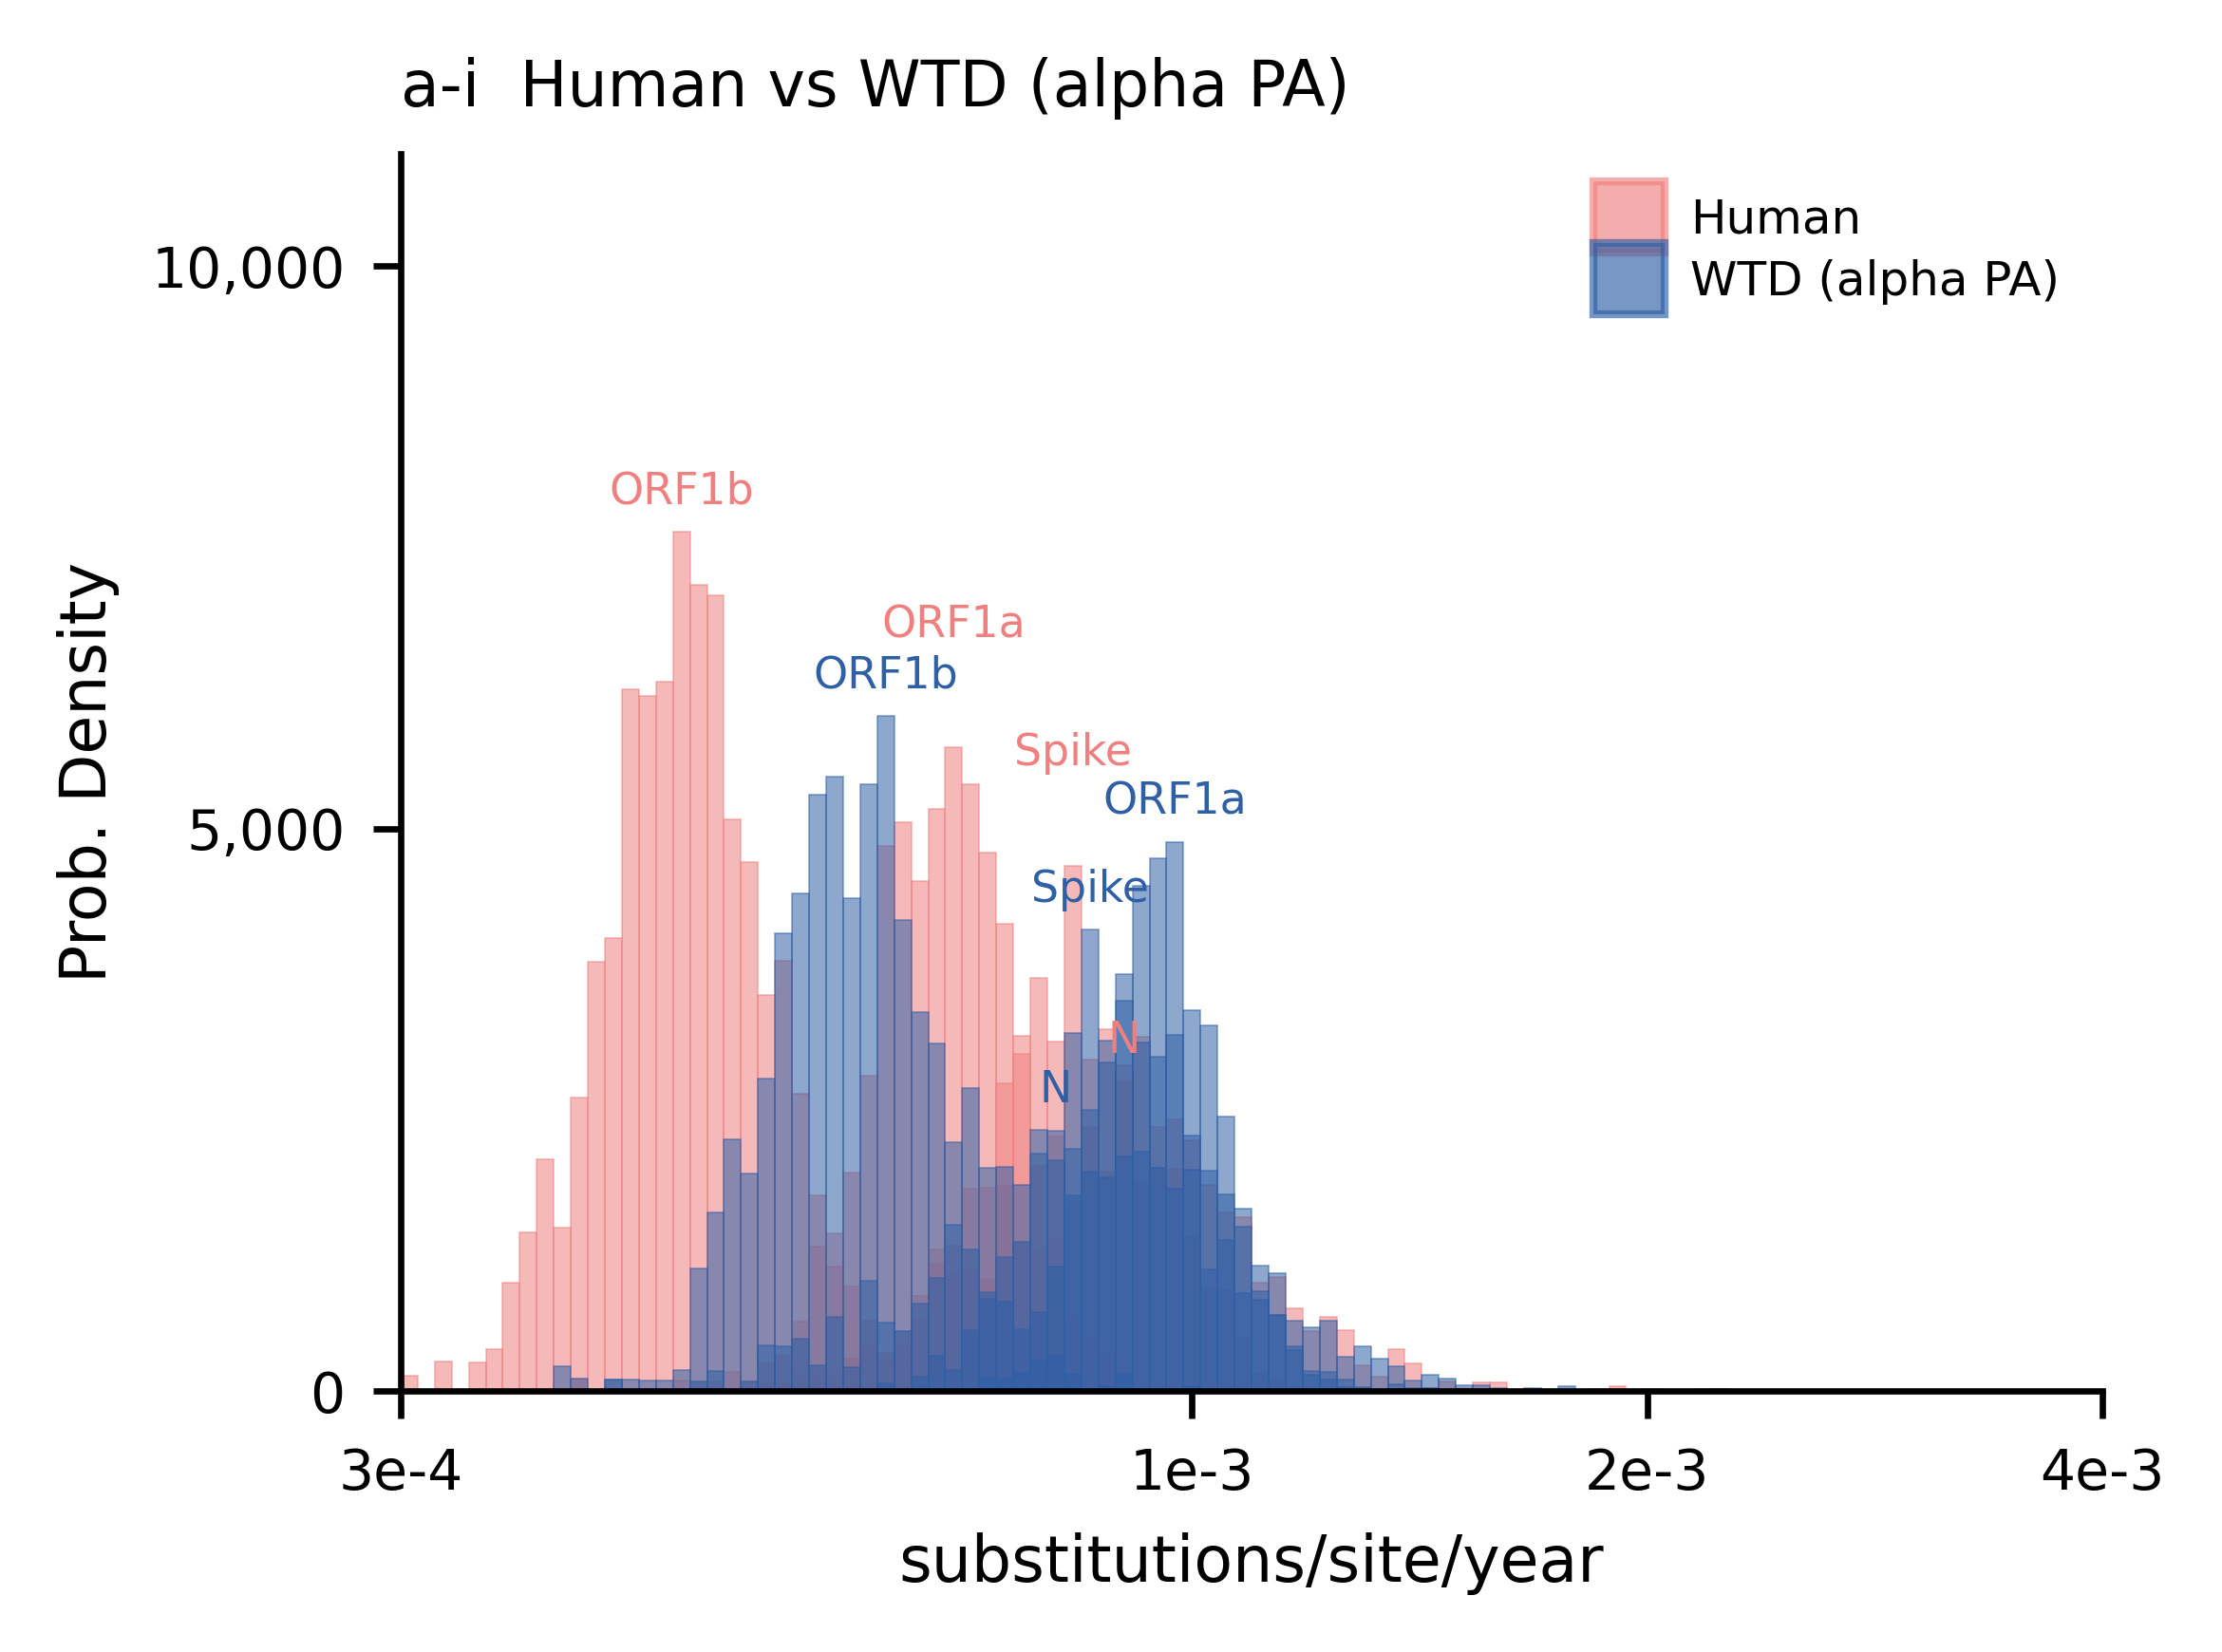

fig7a_ii
wrote ..\figures\fig7a_ii.png


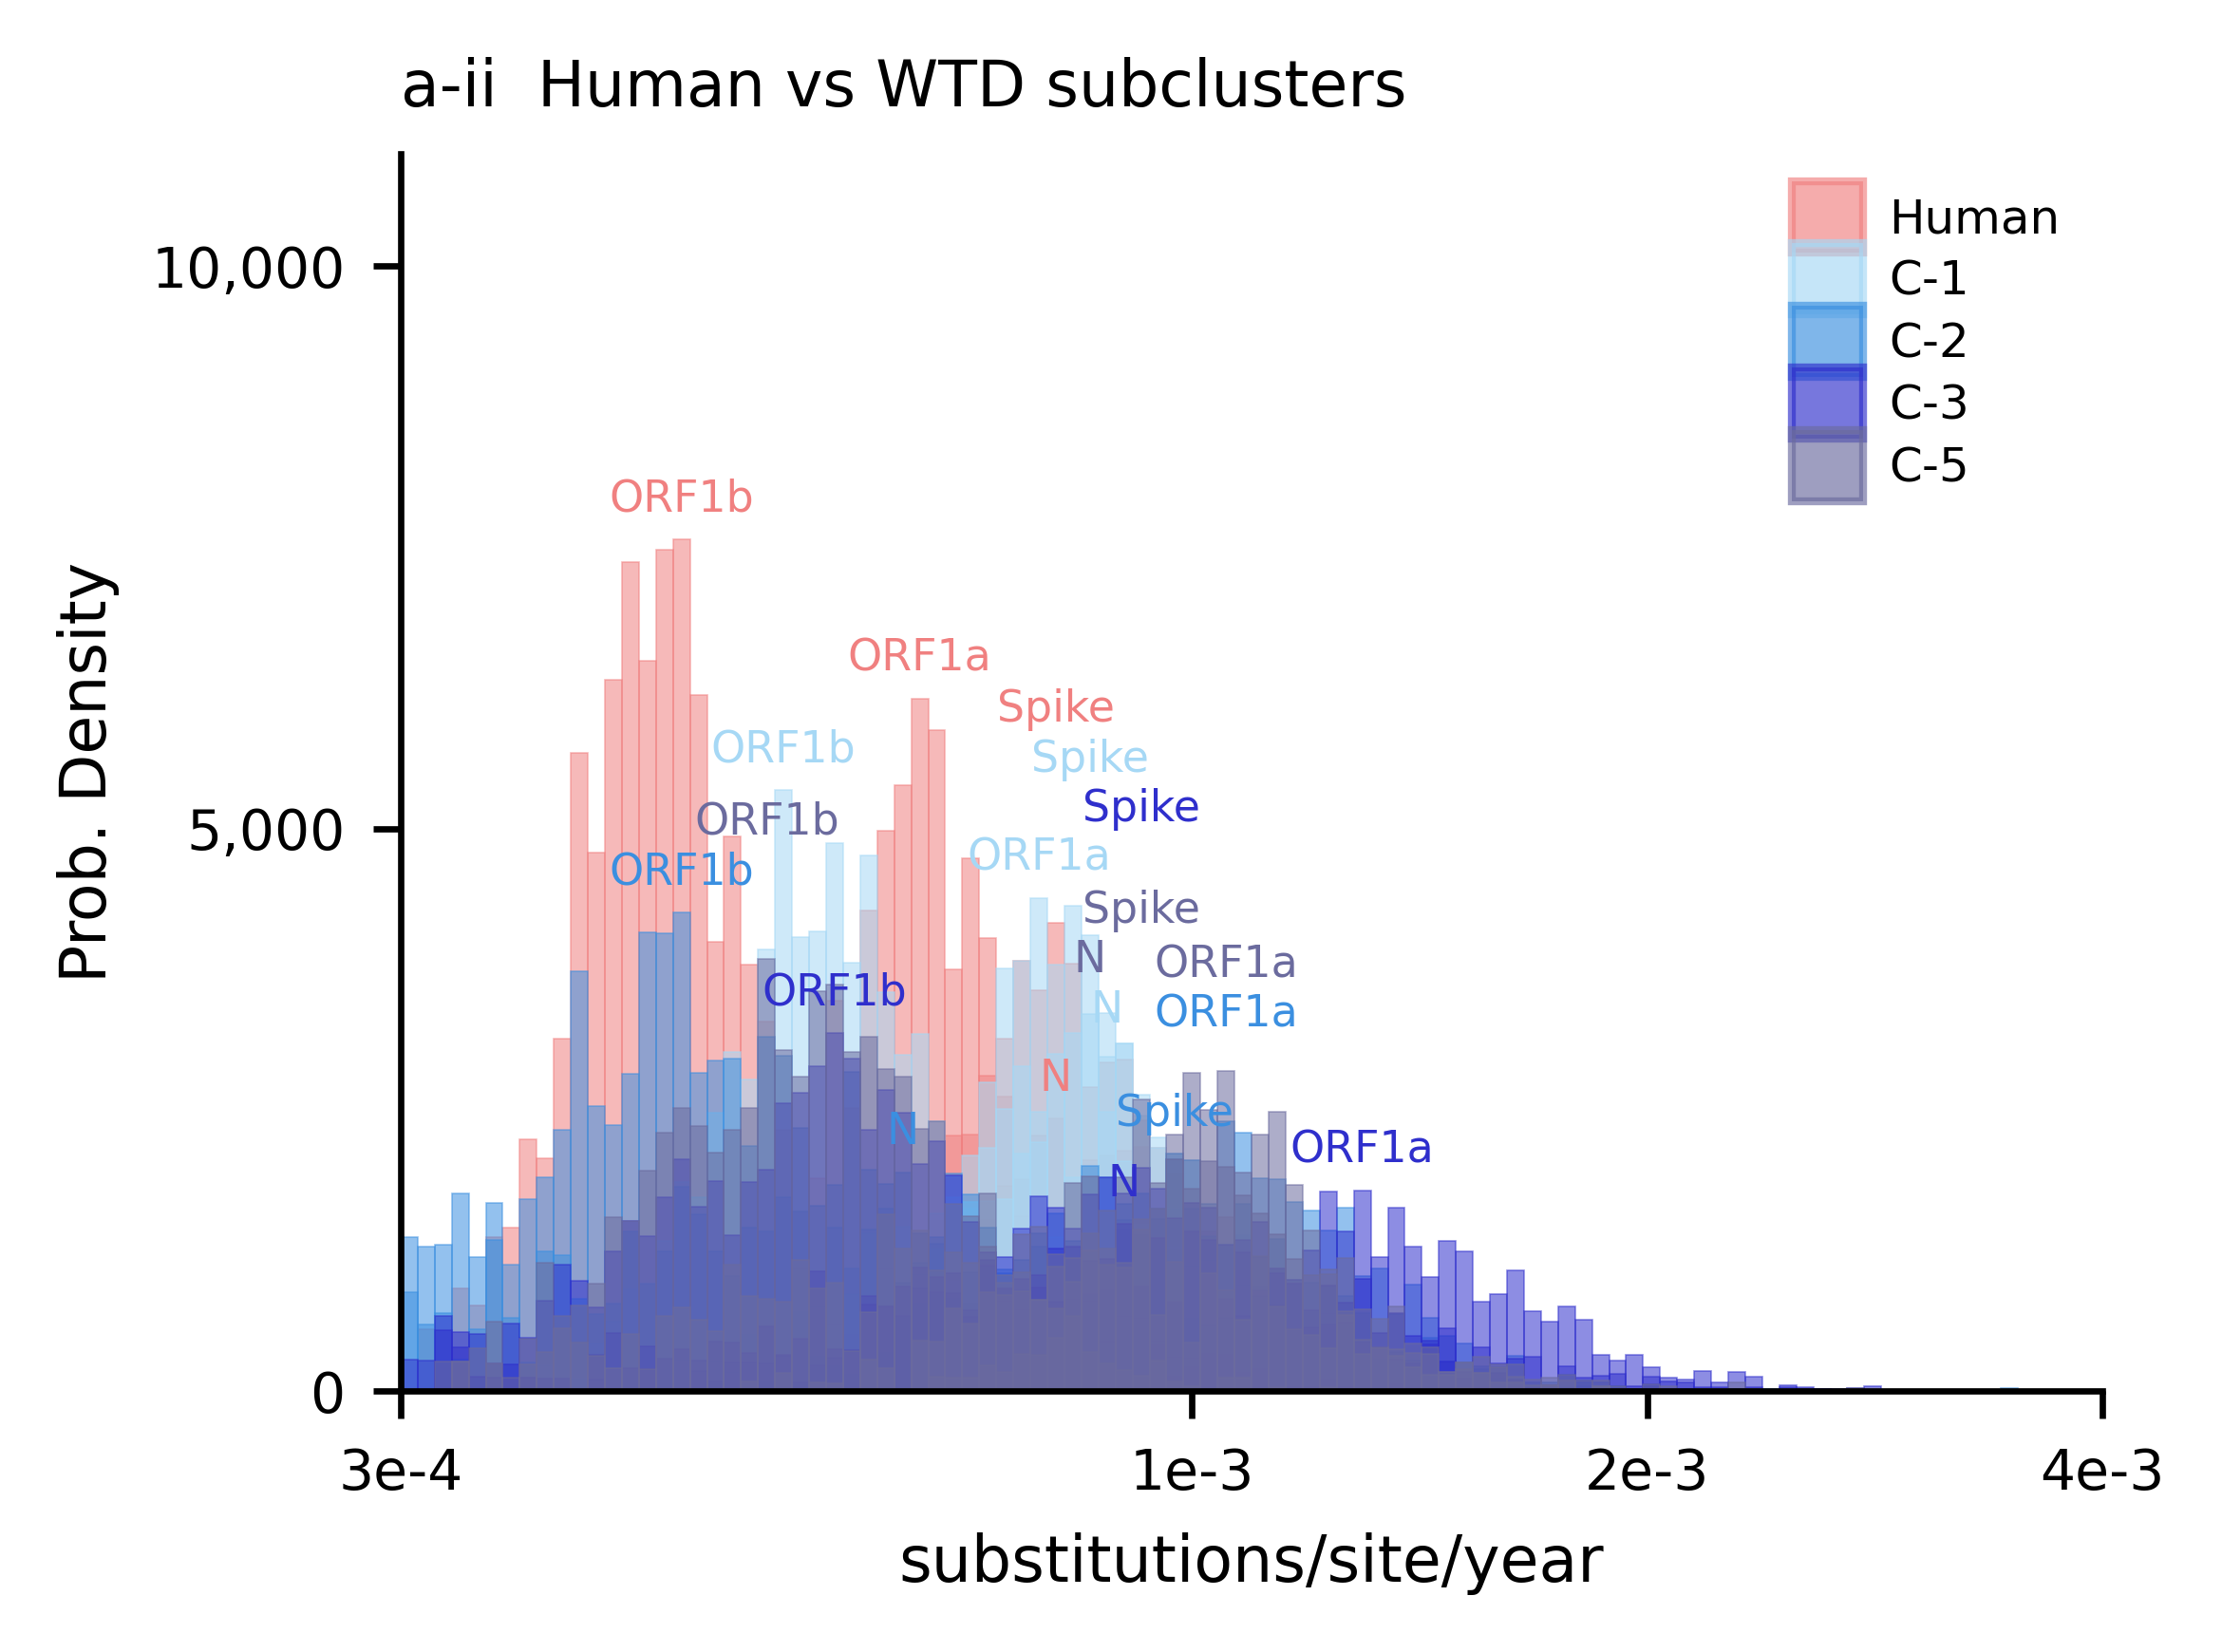

fig7a_iii
wrote ..\figures\fig7a_iii.png


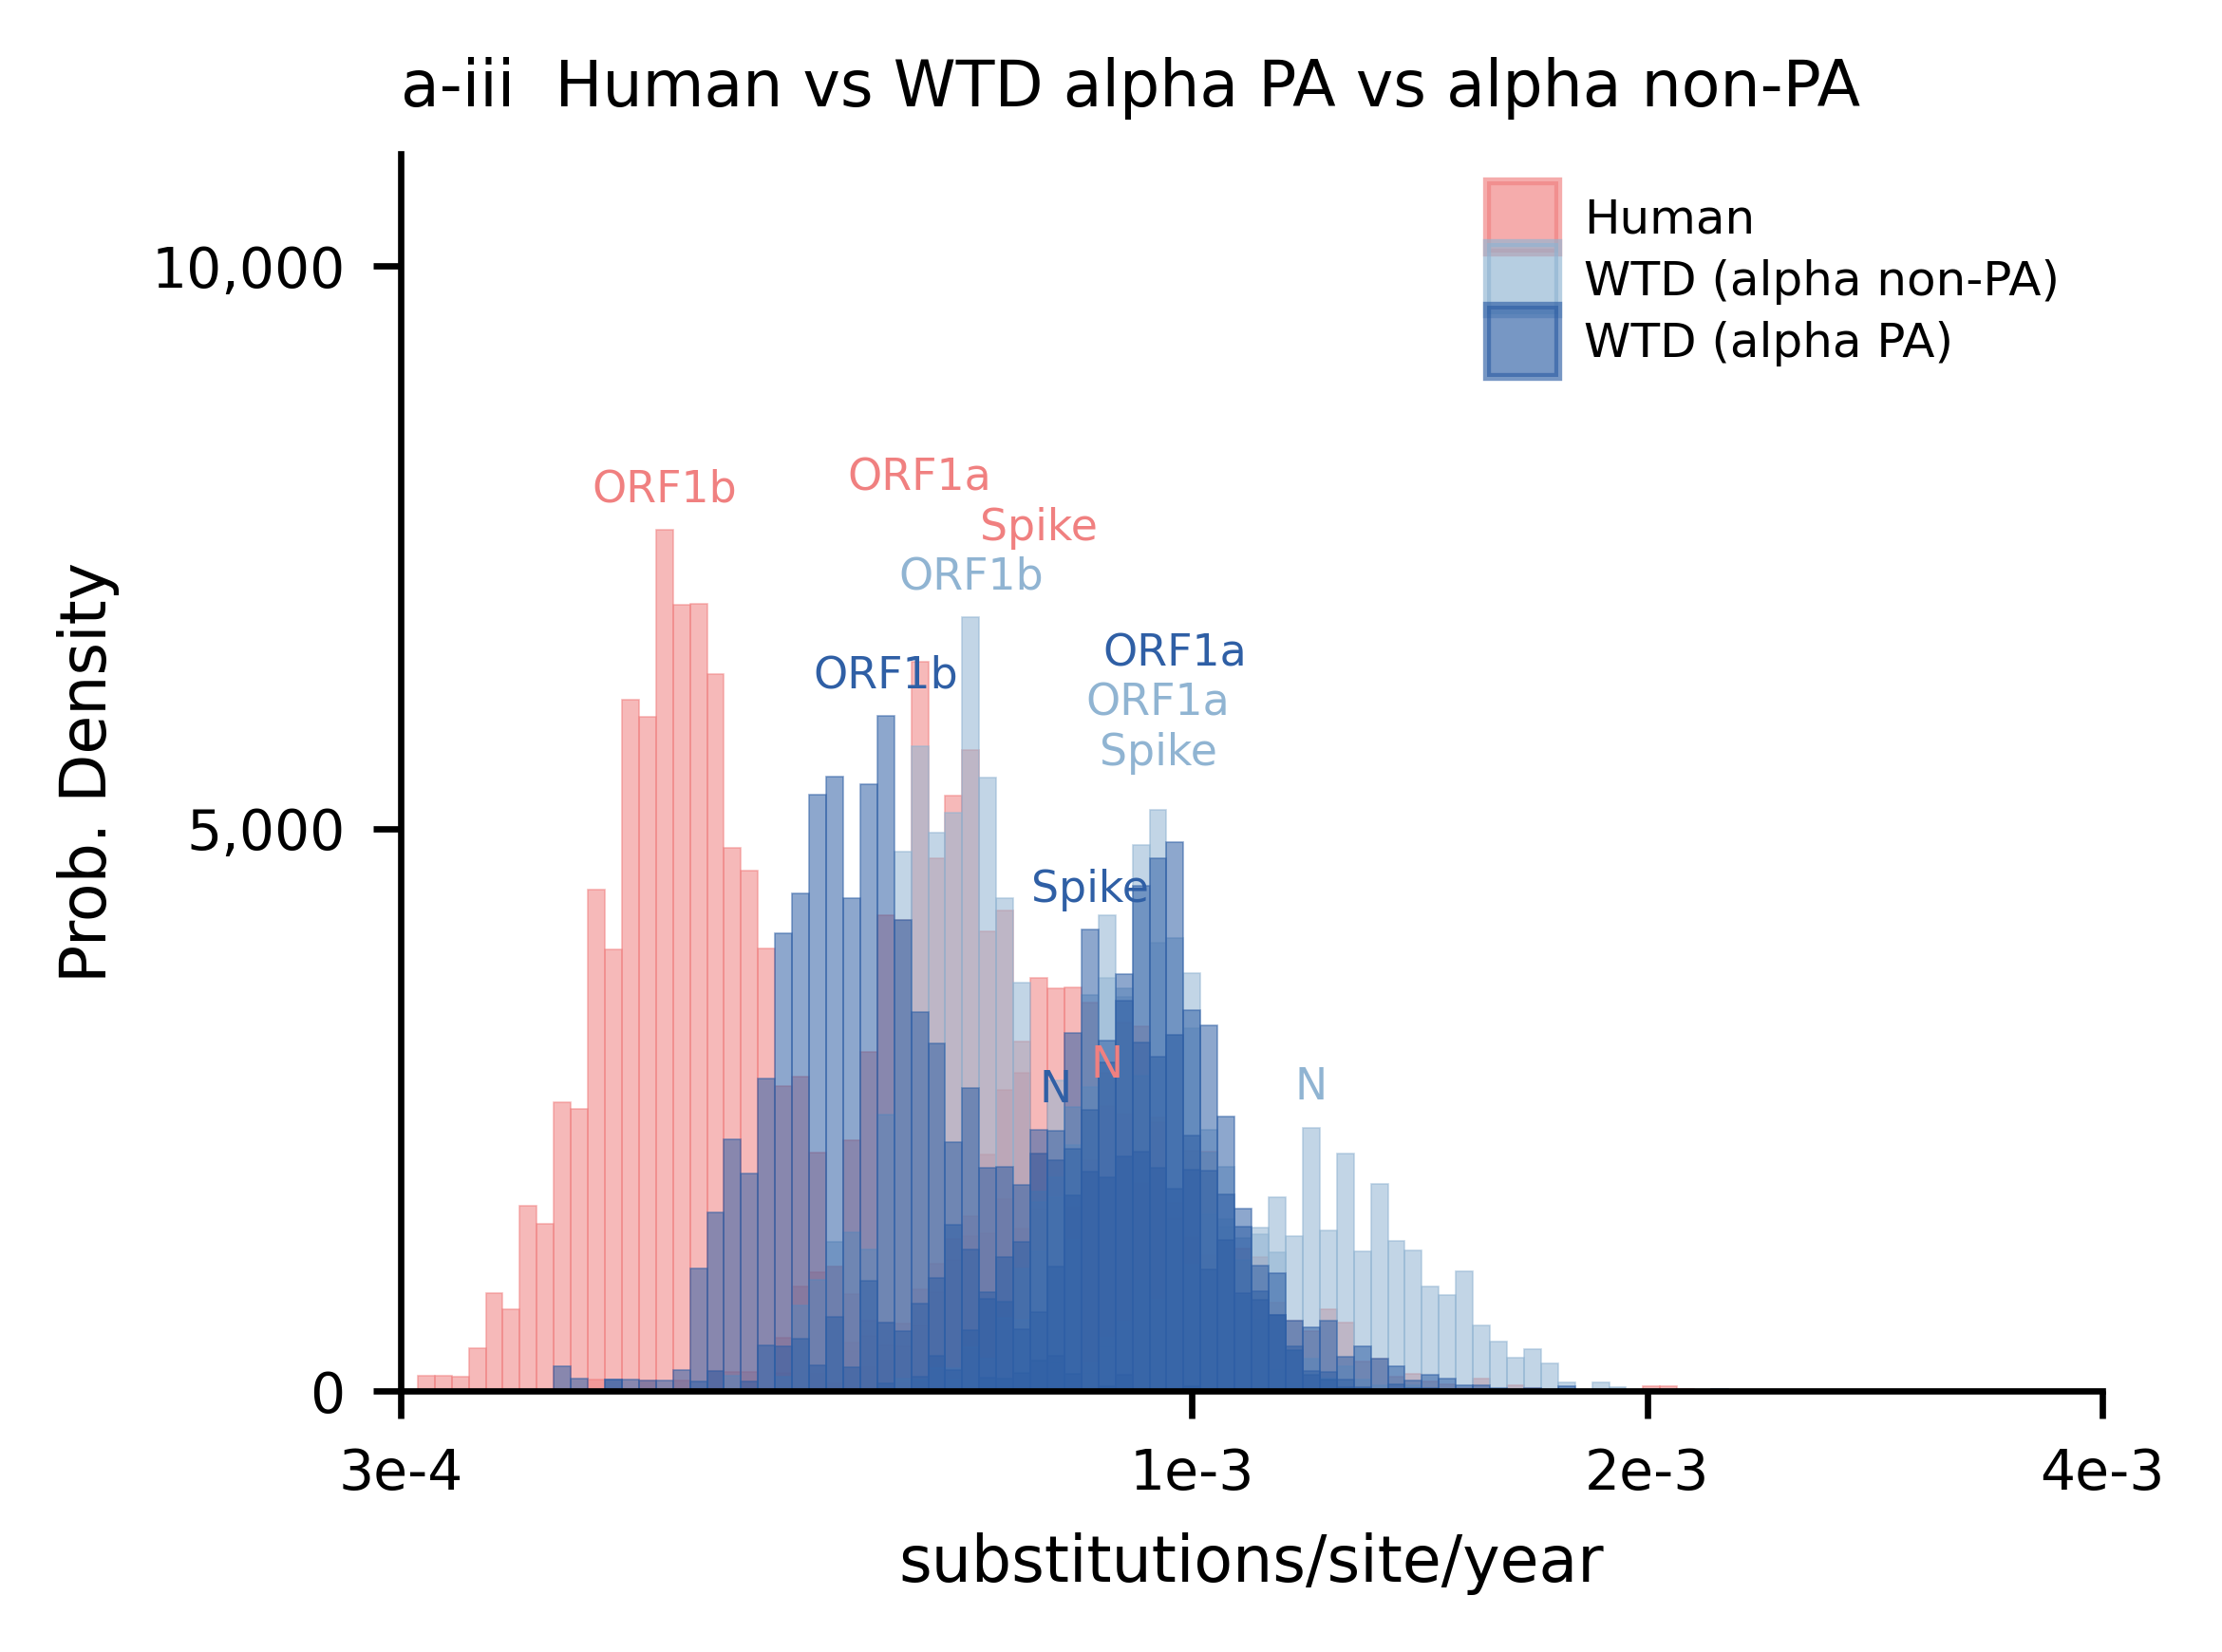

fig7a_iv
wrote ..\figures\fig7a_iv.png


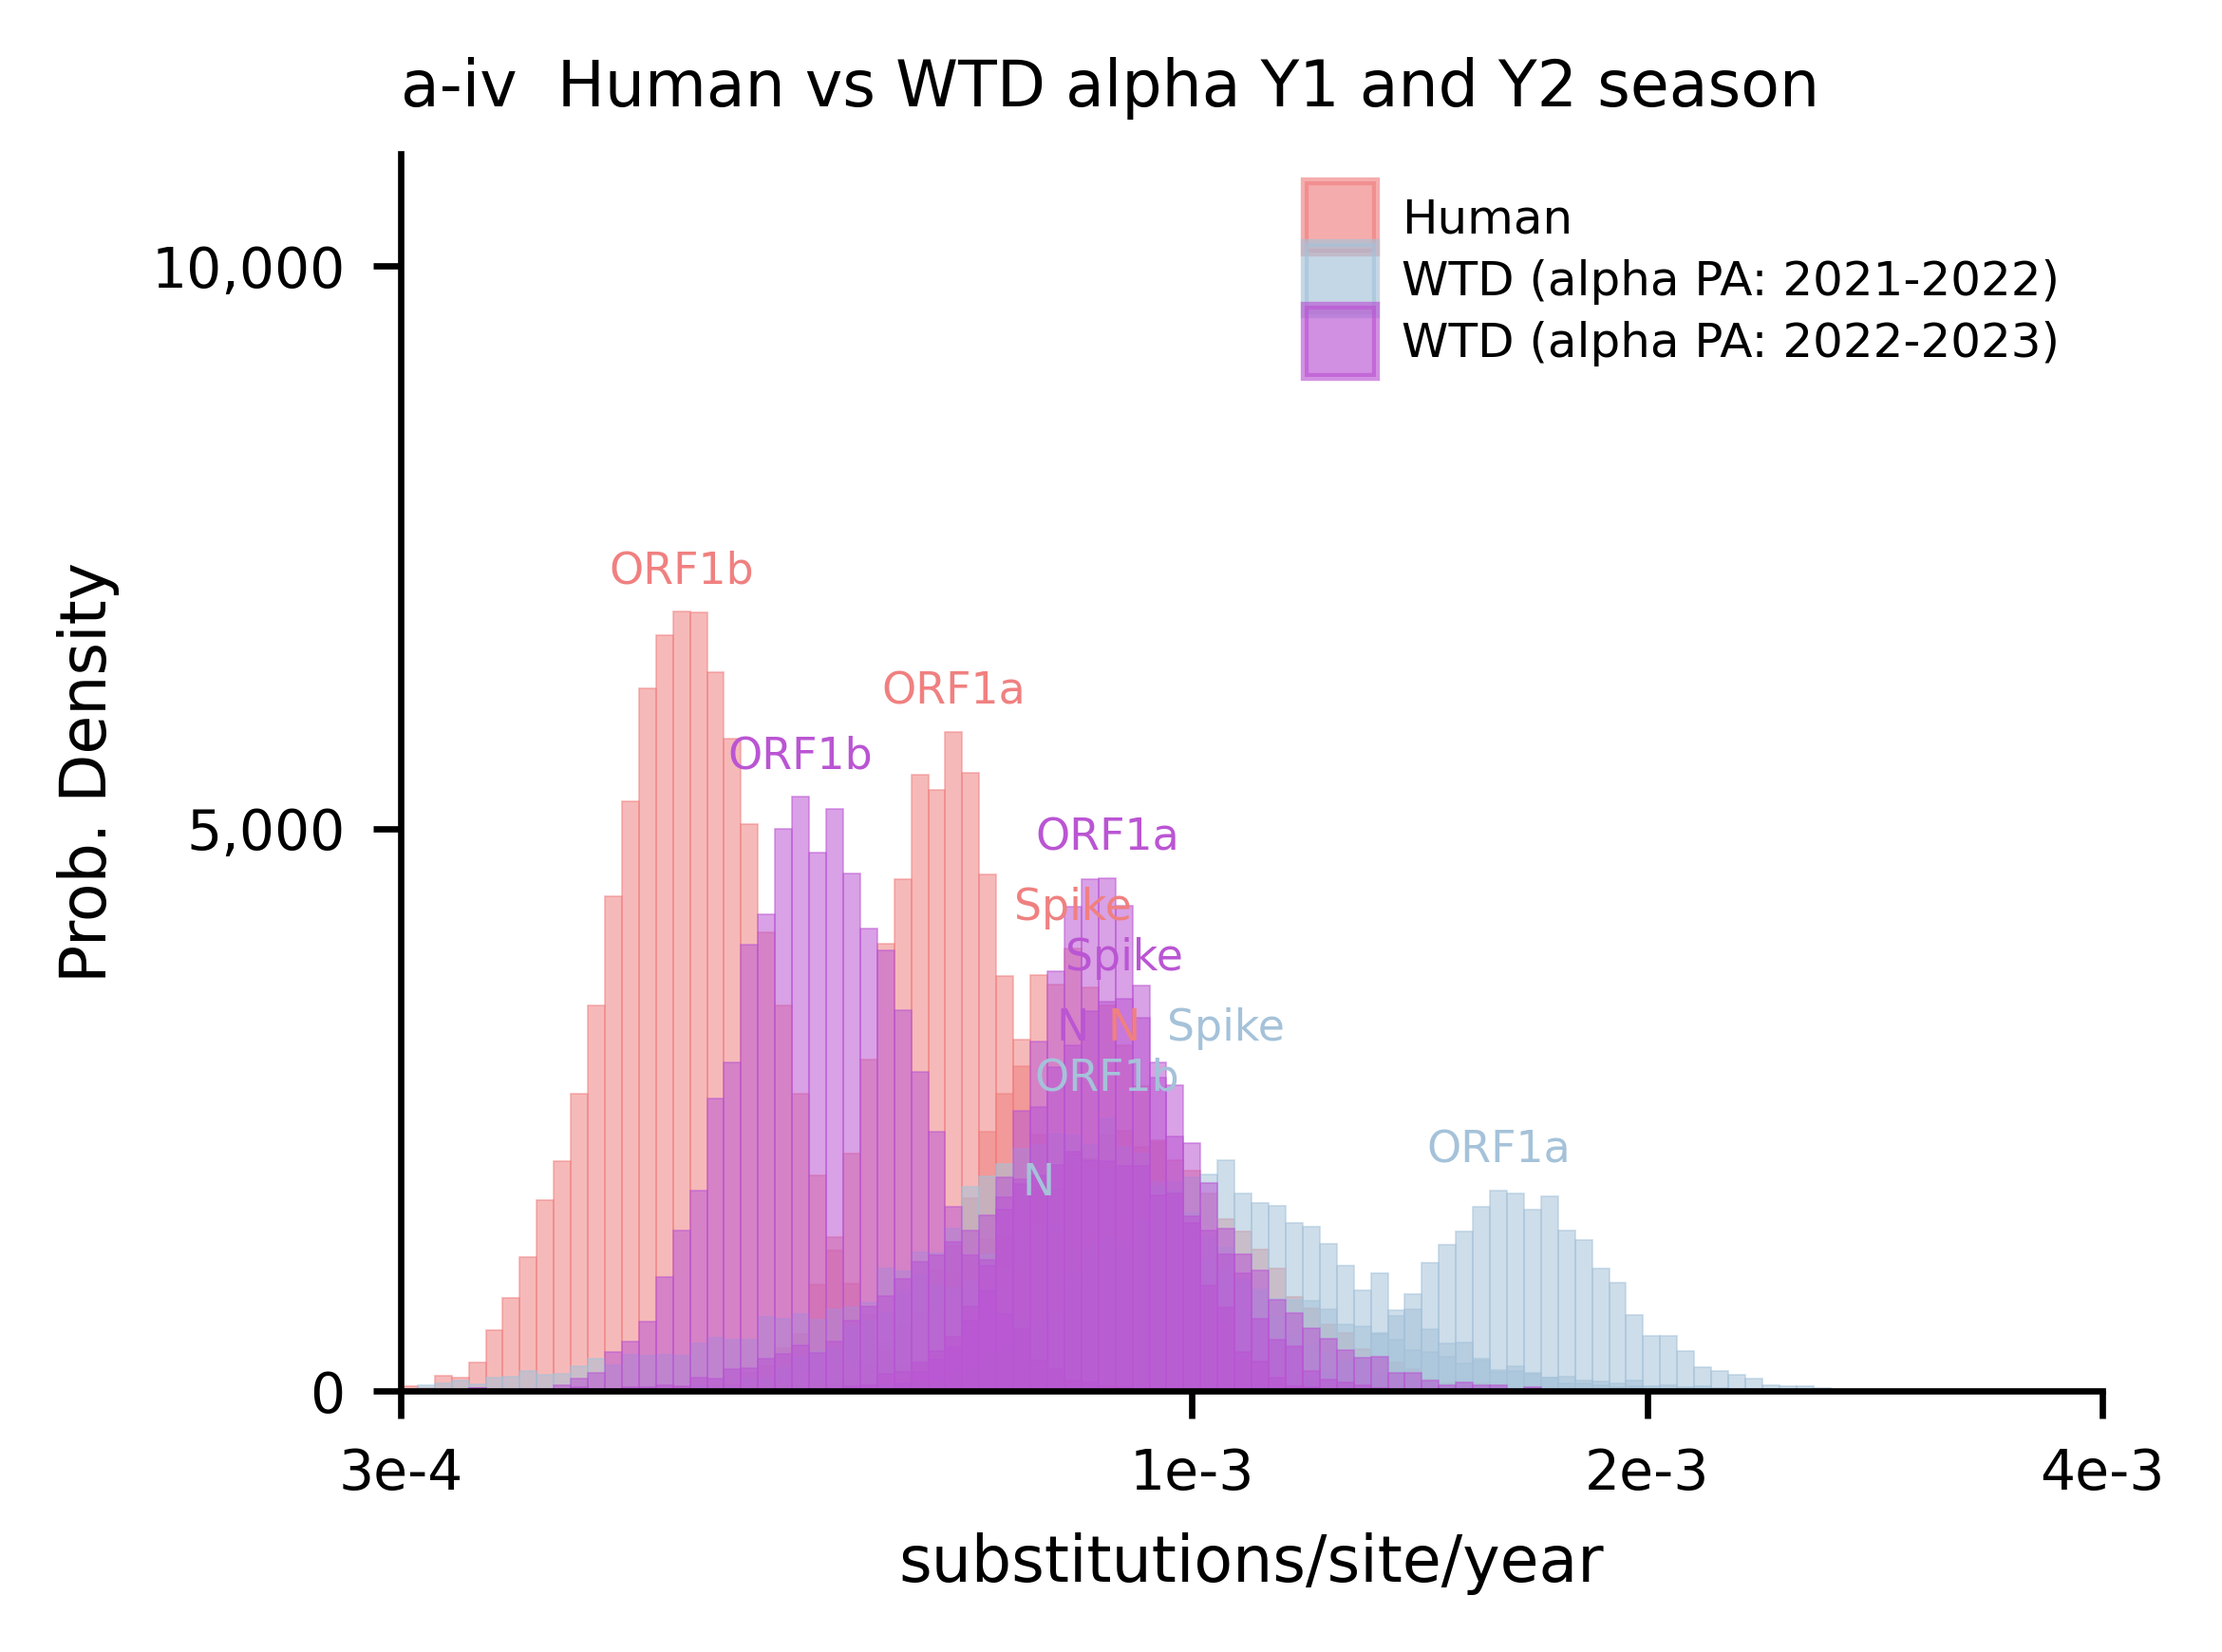

In [17]:
summaries = []
for name, cfg in FIGURES.items():
    print("=" * 70)
    print(name)
    summaries.append(plot_panel(rates, out=name, **cfg))

summary = pd.concat(summaries, ignore_index=True)

## 6. Summary table

Mean, median and 95% HPD per figure, series and partition. This is the table
behind the manuscript numbers and the source-data file.

In [18]:
summary["95% HPD"] = [f"{lo:.3e} to {hi:.3e}"
                      for lo, hi in zip(summary.hpd_low, summary.hpd_high)]

display(summary[["figure", "series", "partition", "posterior_samples",
                 "mean", "95% HPD"]]
        .style.format({"mean": "{:.3e}"}))

summary.to_csv(OUT_DIR / "hostrate_summary.tsv", sep="\t", index=False)
print(f"wrote {OUT_DIR / 'hostrate_summary.tsv'}")

,figure,series,partition,posterior_samples,mean,95% HPD
0,a-i Human vs WTD (alpha PA),Human,Spike,901,8.528e-04,6.535e-04 to 1.060e-03
1,a-i Human vs WTD (alpha PA),Human,ORF1a,901,6.951e-04,5.584e-04 to 8.203e-04
2,a-i Human vs WTD (alpha PA),Human,ORF1b,901,4.725e-04,3.600e-04 to 5.865e-04
3,a-i Human vs WTD (alpha PA),Human,N,901,9.491e-04,6.096e-04 to 1.364e-03
4,a-i Human vs WTD (alpha PA),WTD (alpha PA),Spike,901,9.277e-04,7.384e-04 to 1.175e-03
5,a-i Human vs WTD (alpha PA),WTD (alpha PA),ORF1a,901,9.636e-04,7.953e-04 to 1.125e-03
6,a-i Human vs WTD (alpha PA),WTD (alpha PA),ORF1b,901,6.109e-04,4.673e-04 to 7.499e-04
7,a-i Human vs WTD (alpha PA),WTD (alpha PA),N,901,9.121e-04,5.242e-04 to 1.305e-03
8,a-ii Human vs WTD subclusters,Human,Spike,901,8.203e-04,6.085e-04 to 1.026e-03
9,a-ii Human vs WTD subclusters,Human,ORF1a,901,6.714e-04,5.246e-04 to 8.027e-04


wrote ..\figures\hostrate_summary.tsv
